In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
tips = sns.load_dataset('tips')

# Feature engineering
tips['tip_pct']    = tips['tip'] / tips['total_bill'] * 100
tips['bill_range'] = pd.cut(tips['total_bill'],
                             bins=[0,10,20,30,50],
                             labels=['<$10','$10-20','$20-30','$30+'])

print(tips.shape)
tips.head()

(244, 9)


,total_bill,tip,sex,smoker,day,time,size,tip_pct,bill_range
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,$10-20
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,$10-20
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,$20-30
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,$20-30
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,$20-30


In [3]:
print(tips.describe())
print()
print("Columns:", tips.columns.tolist())
print()
print("Days:  ", tips['day'].unique().tolist())
print("Times: ", tips['time'].unique().tolist())

       total_bill         tip        size     tip_pct
count  244.000000  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672   16.080258
std      8.902412    1.383638    0.951100    6.107220
min      3.070000    1.000000    1.000000    3.563814
25%     13.347500    2.000000    2.000000   12.912736
50%     17.795000    2.900000    2.000000   15.476977
75%     24.127500    3.562500    3.000000   19.147549
max     50.810000   10.000000    6.000000   71.034483

Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size', 'tip_pct', 'bill_range']

Days:   ['Sun', 'Sat', 'Thur', 'Fri']
Times:  ['Dinner', 'Lunch']


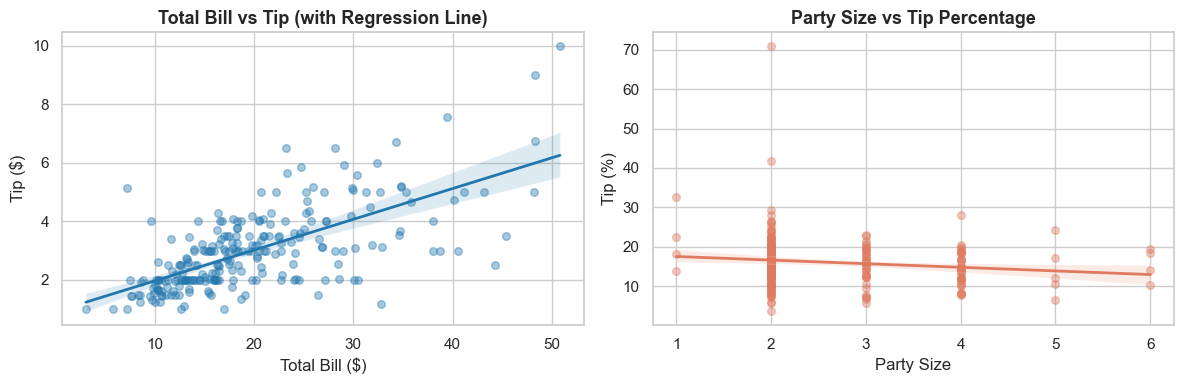

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total bill vs tip
sns.regplot(data=tips, x='total_bill', y='tip',
            color='#2176AE', scatter_kws={'alpha':0.4,'s':30},
            line_kws={'linewidth':2}, ax=axes[0])
axes[0].set_title('Total Bill vs Tip (with Regression Line)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Tip ($)')

# Party size vs tip percentage
sns.regplot(data=tips, x='size', y='tip_pct',
            color='#E07A5F', scatter_kws={'alpha':0.4,'s':30},
            line_kws={'linewidth':2}, ax=axes[1])
axes[1].set_title('Party Size vs Tip Percentage',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Party Size')
axes[1].set_ylabel('Tip (%)')

plt.tight_layout()
plt.show()

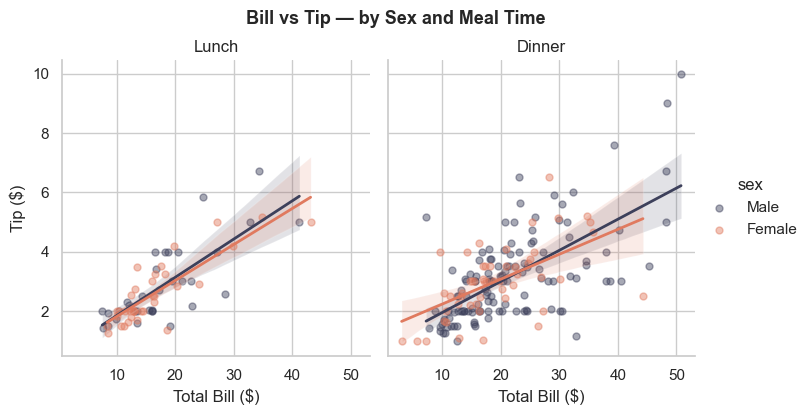

In [5]:
g = sns.lmplot(data=tips, x='total_bill', y='tip',
               hue='sex', col='time',
               palette={'Male':'#3D405B','Female':'#E07A5F'},
               scatter_kws={'alpha':0.45,'s':25},
               line_kws={'linewidth':2},
               height=4, aspect=0.9)

g.set_axis_labels('Total Bill ($)', 'Tip ($)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Bill vs Tip — by Sex and Meal Time',
                   y=1.03, fontsize=13, fontweight='bold')
plt.show()

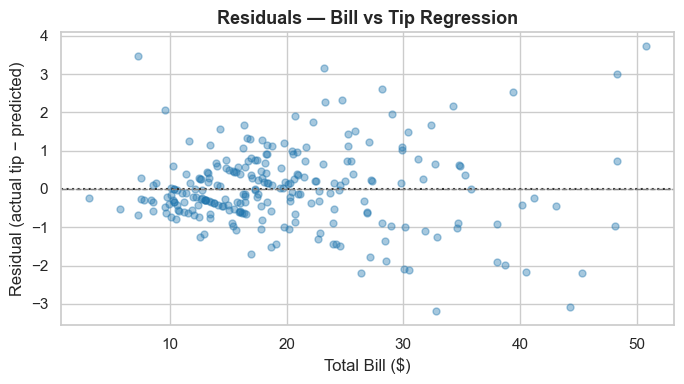

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.residplot(data=tips, x='total_bill', y='tip',
              color='#2176AE', scatter_kws={'alpha':0.4,'s':25}, ax=ax)

ax.axhline(0, color='grey', linewidth=1, linestyle='--')
ax.set_title('Residuals — Bill vs Tip Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Bill ($)')
ax.set_ylabel('Residual (actual tip − predicted)')

plt.tight_layout()
plt.show()